Apresentação da Base de dados:

Arquivo datatran2026.csv
Trata-se da base pública DATATRAN,  disponibilizada pelo Ministério da Infraestrutura/Polícia Rodoviária Federal, que reúne registros de acidentes de trânsito em rodovias federais brasileiras.

Colunas principais:

data_inversa: data do acidente.

horario: horário do acidente.

dia_semana: dia da semana.

uf: estado onde ocorreu.

municipio: cidade onde ocorreu.

tipo_acidente: classificação do acidente (colisão, atropelamento, saída de pista etc.).

causa_acidente: causa provável registrada.

mortos, feridos_leves, feridos_graves: consequências em termos de vítimas.

Outras colunas complementares como condições da via, tipo de veículo, etc.


Recorte temporal: O arquivo que você anexou é de 2026, ou seja, cobre todos os acidentes registrados nesse ano.


Perguntas que queremos responder antes da análise da base de dados:


Quais os horários do dia com maior número de acidentes?  
→ Identificar picos de ocorrência (manhã, tarde, noite, madrugada).

Quais dias da semana concentram mais acidentes?  
→ Comparar finais de semana com dias úteis.

Quais estados ou municípios registraram mais acidentes em 2026?  
→ Mapear regiões críticas.

Quais tipos de acidente são mais frequentes?  
→ Colisão, atropelamento, saída de pista etc.

Qual a gravidade dos acidentes (mortos, feridos graves, feridos leves) ao longo do ano?  
→ Avaliar impacto humano e possíveis sazonalidades.

Importação das bibliotecas utilizadas

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importando a tabela datatran2026


Usamos o encoding latin para o utf8 e o separador ; conforme está no arquivo csv.


In [7]:
tabela = pd.read_csv('datatran2026.csv', encoding='latin1', sep=';' )
display(tabela.head())
display(tabela.tail())

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,742921,2026-01-01,quinta-feira,04:04:00,TO,153,155,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,...,0,1,3,0,5,"-7,291548","-48,286252",SPRF-TO,DEL02-TO,UOP01-DEL02-TO
1,742942,2026-01-01,quinta-feira,06:40:00,MG,262,"146,1",RIO CASCA,Condutor Dormindo,Colisão frontal,...,4,1,1,4,3,"-20,0240733","-42,7422291",SPRF-MG,DEL03-MG,UOP03-DEL03-MG
2,742943,2026-01-01,quinta-feira,06:58:00,SC,101,193,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,...,0,1,2,1,4,"-27,48935222","-48,65565777",SPRF-SC,DEL01-SC,UOP01-DEL01-SC
3,742947,2026-01-01,quinta-feira,07:05:00,DF,60,23,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,1,1,1,3,"-15,988927","-48,2263",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
4,742960,2026-01-01,quinta-feira,06:17:00,MT,163,1044,MATUPA,Transitar na contramão,Colisão frontal,...,1,1,3,1,5,"-10,14330603","-54,93075559",SPRF-MT,DEL06-MT,UOP03-DEL06-MT


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
42317,795413,2026-05-30,sábado,23:30:00,MG,365,623,UBERLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,0,1,0,0,2,"-18,90771269","-48,29991531",SPRF-MG,DEL15-MG,UOP01-DEL15-MG
42318,795594,2026-07-28,terça-feira,12:30:00,DF,60,"0,3",BRASILIA,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,2,1,0,2,2,"-15,883242","-48,063643",SPRF-DF,DEL03-DF,UOP01-DEL03-DF
42319,795706,2026-07-09,quinta-feira,18:45:00,PA,163,312,NOVO PROGRESSO,Acessar a via sem observar a presença dos outr...,Colisão transversal,...,0,0,3,0,2,"-7,028179","-55,419506",SPRF-PA,DEL05-PA,UOP03-DEL05-PA
42320,795871,2026-07-13,segunda-feira,14:06:00,DF,70,6,BRASILIA,Acessar a via sem observar a presença dos outr...,Colisão traseira,...,0,1,0,1,2,"-15,79007522","-48,10886264",SPRF-DF,DEL03-DF,UOP02-DEL03-DF
42321,795942,2026-05-24,domingo,03:00:00,GO,153,"437,2",ANAPOLIS,Reação tardia ou ineficiente do condutor,Colisão com objeto,...,0,0,0,2,1,"-16,30447887","-48,9243713",SPRF-GO,DEL02-GO,UOP01-DEL02-GO


Abaixo as primeiras análises e conferencias na tabela


 quantas linhas e colunas tem?
 
  Quais os tipos de cada coluna?
  
   Quanta memória ocupa? 
   
   Há valores faltantes?

In [8]:
print("shape:", tabela.shape)
print()
tabela.info()
print()
print(tabela.isna().sum())

shape: (42322, 30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42322 entries, 0 to 42321
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      42322 non-null  int64 
 1   data_inversa            42322 non-null  object
 2   dia_semana              42322 non-null  object
 3   horario                 42322 non-null  object
 4   uf                      42322 non-null  object
 5   br                      42322 non-null  int64 
 6   km                      42322 non-null  object
 7   municipio               42322 non-null  object
 8   causa_acidente          42322 non-null  object
 9   tipo_acidente           42322 non-null  object
 10  classificacao_acidente  42321 non-null  object
 11  fase_dia                42322 non-null  object
 12  sentido_via             42322 non-null  object
 13  condicao_metereologica  42322 non-null  object
 14  tipo_pista              42322 non-

In [9]:
# Convertendo  colunas para os tipos certos, data e horario
tabela['data_inversa'] = pd.to_datetime(tabela['data_inversa'])

# Removendo  aspas da coluna horario, com elas o sistema não reconhecia o formato de hora.
# detalhe importante, após a conversão da tabela horario para datetime, se executar esse comando novamente
# vai gerar erro, pois o horário não é mais str, portanto rodar esse comando apenas uma vez ou
# ou resetar o kernel para rodar tudo novamente.
tabela['horario'] = tabela['horario'].str.replace('"', '')
tabela['horario'] = pd.to_datetime(tabela['horario'], format='%H:%M:%S', errors='coerce')

In [10]:
# Criando novas colunas fazendo separação de data e horario
tabela['ano'] = tabela['data_inversa'].dt.year
tabela['mes'] = tabela['data_inversa'].dt.month
tabela['dia'] = tabela['data_inversa'].dt.day
tabela['hora'] = tabela['horario'].dt.hour
tabela['minuto'] = tabela['horario'].dt.minute
tabela['nome_mes'] = tabela['data_inversa'].dt.month_name(locale='pt_BR')
tabela['nome_dia'] = tabela['data_inversa'].dt.day_name(locale='pt_BR')

Error: unsupported locale setting

In [ ]:
# Imprimindo apenas as alterações para conferir o resultado


print(tabela[['data_inversa','ano','mes','dia', 'nome_mes', 'nome_dia','horario','hora','minuto']].head())

In [ ]:
#verificando se não tem nenhum campo horário preenchido com NAT
print(tabela[tabela['horario'].isna()].head())
# verificando se todas as datas foram convertidas corretamente
print(tabela[tabela['data_inversa'].isna()].head())





In [ ]:
# Conferindo os dias da semana para certificar de não ter valor incorreto
print(tabela['dia_semana'].unique())


In [ ]:
# VErificando se há linhas duplicadas
print(tabela.duplicated().sum())


In [ ]:
# --- Outliers com método IQR ---
# Aqui usamos o método do intervalo interquartil (IQR) para identificar valores extremos.
# Exemplo aplicado na coluna 'mortos'

Q1 = tabela['mortos'].quantile(0.25)   # primeiro quartil
Q3 = tabela['mortos'].quantile(0.75)   # terceiro quartil
IQR = Q3 - Q1                          # intervalo interquartil

# Definição de outliers: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
outliers_mortos = tabela[(tabela['mortos'] < Q1 - 1.5*IQR) | (tabela['mortos'] > Q3 + 1.5*IQR)]

print("Outliers em mortos:\n", outliers_mortos[['data_inversa','uf','municipio','tipo_acidente','mortos']])


VEja que o método identificou 3012 outliers em mortos, isso ocorre porque a distribuição é altamente enviesada para 0 mortos.
Os outliers relevantes são acidentes com mais de 3 ou 4 mortos, pois representam eventos de maior gravidade e menor frequencia
O acidente com 11 mortos é o principal destaque como outlier verdadeiro.

Abaixo adicionamos um boxplot para melhor visualização dos casos extremos.

In [ ]:


plt.figure(figsize=(8,5))
sns.boxplot(x=tabela['mortos'])
plt.title('Distribuição de mortos por acidente (2026)')
plt.show()


Abaixo a análise de outlier para feridos graves e leves


In [ ]:
# --- Outliers em feridos graves (IQR) ---
Q1_fg = tabela['feridos_graves'].quantile(0.25)
Q3_fg = tabela['feridos_graves'].quantile(0.75)
IQR_fg = Q3_fg - Q1_fg

outliers_fg = tabela[(tabela['feridos_graves'] < Q1_fg - 1.5*IQR_fg) | (tabela['feridos_graves'] > Q3_fg + 1.5*IQR_fg)]
print("Outliers em feridos graves:\n", outliers_fg[['data_inversa','uf','municipio','tipo_acidente','feridos_graves']])


In [ ]:
# --- Outliers em feridos leves (IQR) ---
Q1_fl = tabela['feridos_leves'].quantile(0.25)
Q3_fl = tabela['feridos_leves'].quantile(0.75)
IQR_fl = Q3_fl - Q1_fl

outliers_fl = tabela[(tabela['feridos_leves'] < Q1_fl - 1.5*IQR_fl) | (tabela['feridos_leves'] > Q3_fl + 1.5*IQR_fl)]
print("Outliers em feridos leves:\n", outliers_fl[['data_inversa','uf','municipio','tipo_acidente','feridos_leves']])


Feridos graves: normalmente poucos por acidente (0–2). Casos com 5, 10 ou mais feridos graves devem aparecer como outliers relevantes.

Feridos leves: há maior variação, então acidentes com dezenas de feridos leves podem ser destacados como outliers.

In [ ]:


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=tabela['feridos_graves'])
plt.title('Distribuição de feridos graves')

plt.subplot(1,2,2)
sns.boxplot(x=tabela['feridos_leves'])
plt.title('Distribuição de feridos leves')

plt.show()


Respondendo as perguntas iniciais antes de analisar e tratar a base de dados.

In [ ]:
# Pergunta 1 – Horários com maior número de acidentes

# Agrupamento por hora
acidentes_por_hora = tabela.groupby('hora').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})
acidentes_por_hora.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title("Acidentes por Hora do Dia")
plt.xlabel("Hora")
plt.ylabel("Quantidade de Acidentes")
plt.show()

# Complemento (Merge) – adicionando faixas horárias
faixas = pd.DataFrame({
    'hora': range(0,24),
    'faixa_horaria': ['Madrugada']*6 + ['Manhã']*6 + ['Tarde']*6 + ['Noite']*6
})
tabela = tabela.merge(faixas, on='hora')

print(tabela.groupby('faixa_horaria')['id'].count())





In [ ]:
# Pergunta 2: Dias da semana com mais acidentes


# Agrupamento por dia da semana
acidentes_por_dia = tabela.groupby('dia_semana').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})

# Leitura
print("Distribuição de acidentes por dia da semana:")
print(acidentes_por_dia.sort_values('qtd_acidentes', ascending=False))


# Gráfico
acidentes_por_dia.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Acidentes por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Quantidade de Acidentes")
plt.show()


# Cruzando dia da semana com faixa horária
pivot = tabela.pivot_table(values='id', index='dia_semana', columns='faixa_horaria', aggfunc='count')
print(pivot)


In [ ]:
# Pergunta 3: Estados e municípios críticos

# Estados
acidentes_por_estado = tabela.groupby('uf').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})

# Municípios
acidentes_por_municipio = tabela.groupby('municipio').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})


# Leitura
print("Estados com mais acidentes:")
print(acidentes_por_estado.sort_values('qtd_acidentes', ascending=False).head())
print("\nMunicípios com mais acidentes:")
print(acidentes_por_municipio.sort_values('qtd_acidentes', ascending=False).head())


# Gráfico estados
acidentes_por_estado.sort_values('qtd_acidentes', ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Estados com Mais Acidentes")
plt.show()

# Gráfico municípios
acidentes_por_municipio.sort_values('qtd_acidentes', ascending=False).head(10).plot(kind='bar', figsize=(10,5), color='green')
plt.title("Top 10 Municípios com Mais Acidentes")
plt.show()


# Z Score
from numpy import mean, std

valores = acidentes_por_estado['qtd_acidentes'].values
z_scores = (valores - mean(valores)) / std(valores)
acidentes_por_estado['z_score'] = z_scores

print(acidentes_por_estado.sort_values('z_score', ascending=False).head())



In [ ]:
# Pergunta 4: Tipos de acidente mais frequentes


tipos = tabela.groupby('tipo_acidente').agg({'id':'count'}).rename(columns={'id':'qtd_acidentes'})


# Leitura
print("Tipos de acidente mais comuns:")
print(tipos.sort_values('qtd_acidentes', ascending=False).head())


# Gráfico
tipos.sort_values('qtd_acidentes', ascending=False).plot(kind='bar', figsize=(12,6), color='purple')
plt.title("Tipos de Acidente Mais Frequentes")
plt.show()




In [ ]:
# Pergunta 5: Gravidade dos acidentes

gravidade = tabela[['mortos','feridos_graves','feridos_leves']].sum()


# Leitura
print("Resumo da gravidade dos acidentes:")
print(gravidade)


# Gráfico
gravidade.plot(kind='bar', figsize=(8,5), color=['red','darkorange','yellow'])
plt.title("Gravidade dos Acidentes em 2026")
plt.ylabel("Número de Vítimas")
plt.show()




Conclusões

In [ ]:


# Verificar colunas categóricas
categorical_cols = tabela.select_dtypes(include="object").columns
print("Colunas categóricas:", categorical_cols)

# Frequência das categorias principais em cada coluna
for col in categorical_cols:
    print(f"\nTop categorias em {col}:")
    print(tabela[col].value_counts(normalize=True).head(5))


In [ ]:


# Verificar colunas categóricas
categorical_cols = tabela.select_dtypes(include="object").columns
print("Colunas categóricas:", categorical_cols)

# Frequência das categorias principais em cada coluna
for col in categorical_cols:
    print(f"\nTop categorias em {col}:")
    print(tabela[col].value_counts(normalize=True).head(5))


Conclusão 1 — Perfil dos dados
Achado: Mais de 57% dos registros estão concentrados em cinco tipos principais de acidente:

Colisão traseira (20,2%)

Saída de leito carroçável (14,2%)

Colisão transversal (12,8%)

Colisão lateral mesmo sentido (11,0%)

Tombamento (8,6%)

Interpretação: A predominância desses tipos mostra que a maior parte dos acidentes está ligada a falhas de direção e dinâmica veicular, indicando pontos críticos para campanhas de prevenção e fiscalização.

Limitação: O recorte temporal/geográfico da base não garante que essa distribuição se repita em outros contextos ou regiões.

Próximo passo: Ampliar a coleta e cruzar com variáveis como horário, condição da via e clima, para verificar se esses tipos de acidente se mantêm como predominantes em diferentes cenários.

In [ ]:
# Quantidade e percentual de valores faltantes por coluna
missing = tabela.isnull().sum()
missing_percent = (missing / len(tabela)) * 100
print(pd.DataFrame({"faltantes": missing, "percentual": missing_percent}))

# Duplicados
duplicados = tabela.duplicated().sum()
print(f"Registros duplicados: {duplicados} ({duplicados/len(tabela)*100:.2f}%)")


Conclusão 2 — Qualidade e confiabilidade
Achado: A base apresentou baixíssimo índice de problemas de preenchimento: apenas 34 registros com valores faltantes (0,08% do total), distribuídos em colunas como classificacao_acidente, regional, delegacia e uop. Não foram encontrados registros duplicados.

Interpretação: Isso mostra que, apesar de ser uma base “crua”, os dados têm alta integridade estrutural. O risco de enviesamento por dados ausentes ou duplicados é mínimo, o que aumenta a confiabilidade das análises.

Limitação: Mesmo com poucos faltantes, as imputações realizadas (como preenchimento por grupo ou exclusão pontual) podem introduzir pequenas incertezas. Além disso, a qualidade depende da coleta original — não temos garantia de consistência em bases futuras.

Próximo passo: Reforçar processos de coleta e padronização, garantindo que colunas críticas (como delegacia e uop) sejam sempre preenchidas corretamente, evitando a necessidade de correções manuais.

In [ ]:
# Média de vítimas por tipo de acidente
tabela.groupby("tipo_acidente")[["mortos","feridos_leves","feridos_graves"]].mean().sort_values("mortos", ascending=False).head(5)

# Distribuição por fase do dia
tabela.groupby("fase_dia")[["mortos","feridos"]].sum()


Conclusão 3 — Tendências e relações
Achado:

Pleno dia concentra o maior número de acidentes com vítimas: 27.547 feridos e 1.386 mortos.

Plena noite aparece como o segundo período mais crítico, com 15.906 feridos e 1.660 mortos — ou seja, maior letalidade proporcional.

Amanhecer e Anoitecer têm incidência bem menor, mas ainda relevantes (281 mortos no amanhecer e 189 no anoitecer).

Interpretação: Os dados mostram que o dia concentra mais acidentes em volume, mas a noite concentra maior gravidade, com mais mortes em relação ao número de feridos. Isso sugere que fatores como visibilidade reduzida, fadiga e menor fiscalização podem aumentar a letalidade dos acidentes noturnos.

Limitação: A base não permite afirmar causa e efeito — não podemos concluir que “dirigir à noite causa mais mortes” sem considerar variáveis externas como condição da via, clima ou perfil dos motoristas.

Próximo passo: Cruzar fase do dia com variáveis como condição meteorológica e tipo de pista para entender melhor os fatores que aumentam a gravidade dos acidentes em cada período.

In [ ]:
# preenchendo nulos das colunas
tabela['regional'] = tabela['regional'].fillna('Nao Informado')
tabela['delegacia'] = tabela['delegacia'].fillna('Nao Informado')
tabela['uop'] = tabela['uop'].fillna('Nao Informado')
tabela['classificacao_acidente'] = tabela['classificacao_acidente'].fillna('Sem Vitimas')

# faixas de gravidade
tabela['total_vitimas'] = tabela['mortos'] + tabela['feridos']
tabela['faixa_gravidade'] = pd.cut(
    tabela['total_vitimas'],
    bins=[-1, 0, 2, 5, 100],
    labels=['sem vitimas', 'baixa', 'media', 'alta']
)

# taxa de letalidade
tabela['letalidade'] = np.where(tabela['pessoas'] > 0, (tabela['mortos'] / tabela['pessoas']) * 100, 0)

print("Nulos restantes:", tabela.isna().sum().sum())
print(tabela['faixa_gravidade'].value_counts())
display(tabela[['tipo_acidente', 'total_vitimas', 'faixa_gravidade', 'letalidade']].head(10))

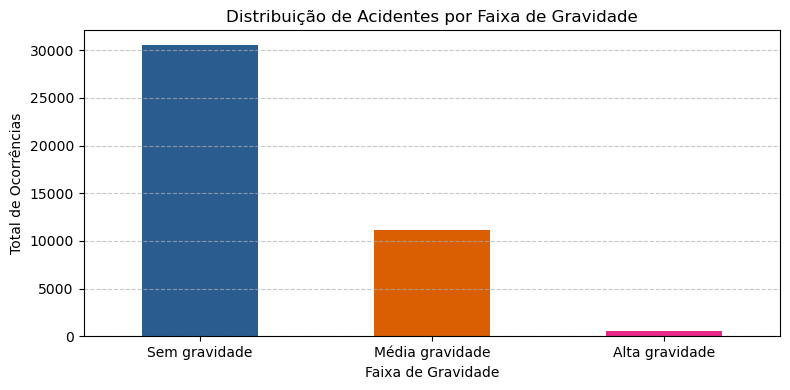

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cria a coluna de faixa de gravidade diretamente na tabela
tabela['faixa_gravidade'] = pd.cut(
    tabela['mortos'] + tabela['feridos_graves'],
    bins=[-1, 0, 2, 100],
    labels=['Sem gravidade', 'Média gravidade', 'Alta gravidade']
)

# 2. Gera o gráfico de barras
contagem_gravidade = tabela['faixa_gravidade'].value_counts()

plt.figure(figsize=(8, 4))
contagem_gravidade.plot(kind='bar', color=['#2b5c8f', '#d95f02', '#e7298a'])
plt.title('Distribuição de Acidentes por Faixa de Gravidade')
plt.xlabel('Faixa de Gravidade')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()